In [145]:
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
import numpy as np
from scipy import stats

In [146]:
fname = "/Users/jacksontobin/Local_Documents/NightTime_Research/ANGSTROM/Star_Photometry/Angstrom3_ColState/Angstrom_Overnight_2026_04_01_032300_042815/Angstrom_Overnight_2026_04_01_allBands_Langley.xlsx"
df = pd.read_excel(fname, sheet_name=None)

## Histrograms

In [158]:
def make_hist_single(dataframe, band="450", color='blue'):
    kde = stats.gaussian_kde(dataframe[f'Band {band}']['Langley_slope'])

    fig, ax = plt.subplots(figsize=(6,4))
    ax.hist(
        dataframe[f'Band {band}']['Langley_slope'],
        bins=20,
        # edgecolor='grey',
        color=color,
        alpha=0.6,
        range=(-0.1, 1.0),
        density=True
        )
    ax.set_xlabel('Langley Slope')
    ax.set_ylabel('Star Counts')
    ax.set_title(f'Langley Slope Distribution: Band {band}nm')
    xx = np.linspace(np.amin(dataframe[f'Band {band}']['Langley_slope']), 
                     np.amax(dataframe[f'Band {band}']['Langley_slope']),
                     1000)
    ax.plot(xx, kde(xx), color='black', alpha=0.8)
    plt.tight_layout()
    plt.show()

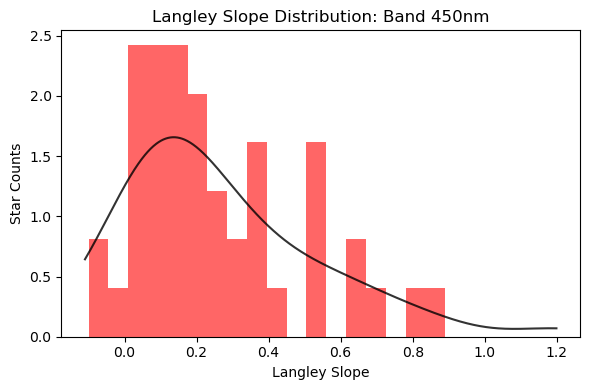

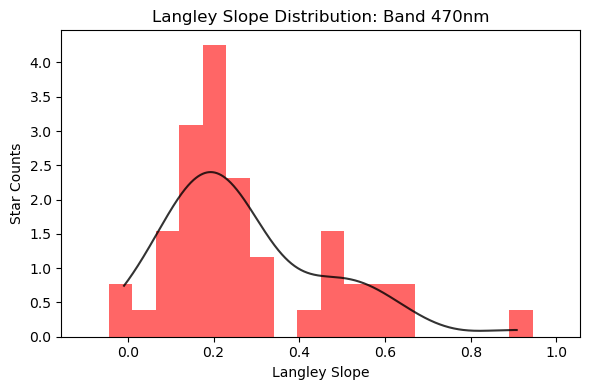

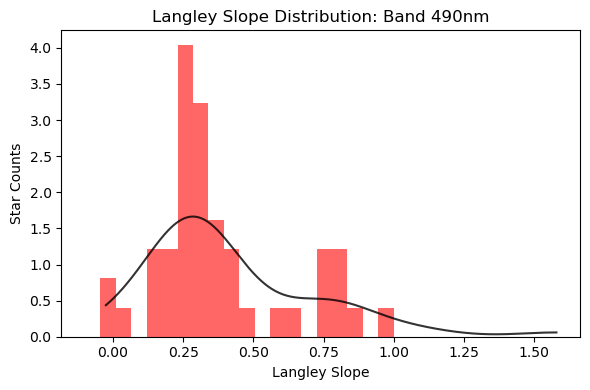

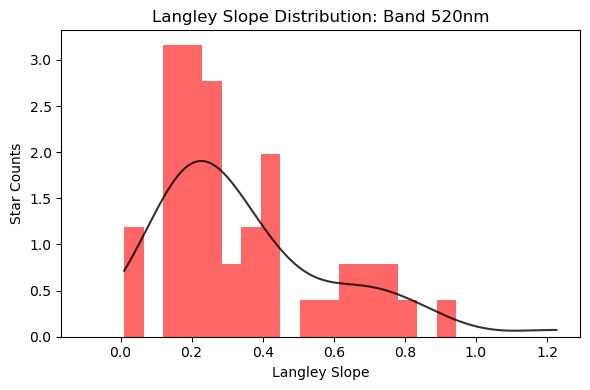

In [159]:
make_hist_single(dataframe=df, band='450', color='red')
make_hist_single(dataframe=df, band='470', color='red')
make_hist_single(dataframe=df, band='490', color='red')
make_hist_single(dataframe=df, band='520', color='red')

## Box Plots

In [149]:
def make_box(data):
    fig, ax = plt.subplots(figsize=(6,4))
    bp = ax.boxplot(data, patch_artist=True,
                    showmeans=True,
                    meanline=True)
    for patch in bp['boxes']: 
        patch.set(facecolor='red',
                  alpha=0.6)
    for median in bp['medians']:
        median.set(color='black',
                   linewidth=2,
                   linestyle=':')
    for mean in bp['means']:
        mean.set(color='black',
                 linewidth=2,
                 linestyle='-')
    for flier in bp['fliers']:
        flier.set(color='#e7298a',
                  alpha=0.5)
    for whisker in bp['whiskers']:
        whisker.set(color ='black',
                linewidth = 1,
                linestyle ="--")
    ax.set_xticks([1, 2, 3, 4])
    ax.set_xticklabels(['450nm', '470nm', '490nm', '520nm'])
    ax.set_yticks(np.arange(-0.2, 1.5, 0.1))
    ax.set_ylim(-0.2, 1.5)
    ax.set_ylabel('AOD')
    ax.set_title('AOD All Bands')
    # ax.set_ylim(0.0, 0.8)
    ax.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


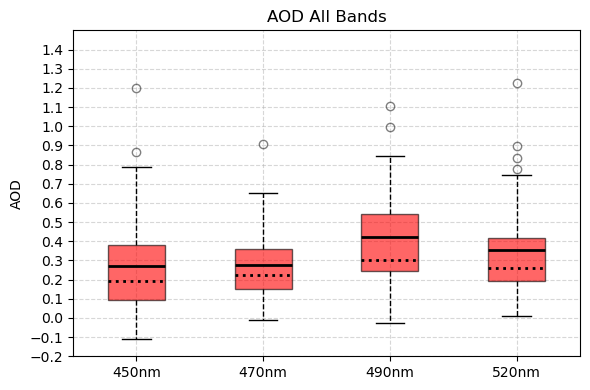

In [150]:

data = [df['Band 450']['Langley_slope'], df['Band 470']['Langley_slope'], df['Band 490']['Langley_slope'], df['Band 520']['Langley_slope']]
make_box(data)

## Angstrom Exponents

In [151]:
lambda1 = np.array([450, 470, 490, 520])
median = [np.median(i) for i in data]
mean = [np.mean(i) for i in data]
std = [np.std(i) for i in data]

tau = np.array(median)

angstrom = np.log(tau[:-1] / tau[1:]) / np.log(lambda1[:-1] / lambda1[1:])
for i in range(len(angstrom)):
    band_range = f"{lambda1[:-1][i]}-{lambda1[1:][i]}nm"
    print(fr"Angstrom Exponent for {band_range}: {angstrom[i]:.4f}")

Angstrom Exponent for 450-470nm: 3.3940
Angstrom Exponent for 470-490nm: 7.5074
Angstrom Exponent for 490-520nm: -2.4599
